In [ ]:
#| hide
from programming_first_principles.core import prepare_notebook
from programming_first_principles.helpers.cost import Cost
from programming_first_principles.algorithms.sort import scores_out_of_100
from programming_first_principles.algorithms.sort import is_sorted

In [ ]:
#| hide
prepare_notebook()

# Adjacent Exchange

## Sort Introduction

#### sort2

In [ ]:
#| exports algorithms.sort
from programming_first_principles.ordering import out_of_order

def sort2(x, y):
    if out_of_order(x, y):
        return y, x
    return x, y

In [ ]:
f'already sorted: {sort2(5, 10) = }'
f'equal: {sort2(5, 5) = }'
f'out of order: {sort2(10, 5) = }'

'already sorted: sort2(5, 10) = (5, 10)'

'equal: sort2(5, 5) = (5, 5)'

'out of order: sort2(10, 5) = (5, 10)'

#### sort3

In [ ]:
#| exports algorithms.sort
def sort3(x, y, z):
    x, y = sort2(x, y)
    y, z = sort2(y, z)
    x, y = sort2(x, y)
    return x, y, z

In [ ]:
f'already sorted: {sort3(5, 10, 35) = }'
f'all equal: {sort3(5, 5, 5) = }'

'already sorted: sort3(5, 10, 35) = (5, 10, 35)'

'all equal: sort3(5, 5, 5) = (5, 5, 5)'

In [ ]:
f'equals already in place: {sort3(5, 5, 10) = }'
f'the 10 moves to the end: {sort3(10, 5, 5) = }'
f'the middle is out of order: {sort3(5, 10, 5) = }'
f'equals at the ends: {sort3(10, 5, 10) = }'

'equals already in place: sort3(5, 5, 10) = (5, 5, 10)'

'the 10 moves to the end: sort3(10, 5, 5) = (5, 5, 10)'

'the middle is out of order: sort3(5, 10, 5) = (5, 5, 10)'

'equals at the ends: sort3(10, 5, 10) = (5, 10, 10)'

In [ ]:
f'only the first pair: {sort3(10, 5, 35) = }'
f'only the second pair: {sort3(5, 35, 10) = }'
f'reversed: {sort3(35, 10, 5) = }'
f'largest starts first and finishes last: {sort3(35, 5, 10) = }'

'only the first pair: sort3(10, 5, 35) = (5, 10, 35)'

'only the second pair: sort3(5, 35, 10) = (5, 10, 35)'

'reversed: sort3(35, 10, 5) = (5, 10, 35)'

'largest starts first and finishes last: sort3(35, 5, 10) = (5, 10, 35)'

#### Bubble Sort

In [ ]:
#| exports algorithms.sort
def bubble_pass(a, first, last):
    for i in range(first, last - 1):
        a[i], a[i + 1] = sort2(a[i], a[i + 1])

def bubble_sort(a, first, last):
    while last - first > 1:
        bubble_pass(a, first, last)
        last -= 1

In [ ]:
a = list(scores_out_of_100)
bubble_pass(a, 0, len(a))
f'one pass, largest finishes last: {a = }'

b = list(scores_out_of_100)
f'Before: {b = }, {is_sorted(b, 0, len(b)) = }'
bubble_sort(b, 0, len(b))
f'After: {b = }, {is_sorted(b, 0, len(b)) = }'


'one pass, largest finishes last: a = [10, 35, 5, 40, 75, 5, 80, 80]'

'Before: b = [40, 10, 35, 5, 80, 75, 5, 80], is_sorted(b, 0, len(b)) = False'

'After: b = [5, 5, 10, 35, 40, 75, 80, 80], is_sorted(b, 0, len(b)) = True'

In [ ]:
scores_bub = list(scores_out_of_100)
bub = Cost(repeats=1)
_ = bub.run(bubble_sort, scores_bub.copy(), 0, len(scores_bub),
        name='bubble_sort', shape='scores',
        operations=('comparisons', 'swaps', 'ms'))
bub.frame

,algo,shape,n,comparisons,predicates,swaps,ms
0,bubble_sort,scores,8,28,None,28,0.0069


In [ ]:
bub_scale = Cost(repeats=3, sizes=(200, 400, 800))
bub_scale.scale(bubble_sort, operations=('comparisons', 'swaps', 'ms'))

,algo,shape,n,comparisons,predicates,swaps,ms
0,bubble_sort,random,200,19900,None,19900,2.3317
1,bubble_sort,sorted,200,19900,None,19900,3.6781
2,bubble_sort,reversed,200,19900,None,19900,2.5387
3,bubble_sort,random,400,79800,None,79800,8.6266
4,bubble_sort,sorted,400,79800,None,79800,8.4839
5,bubble_sort,reversed,400,79800,None,79800,8.1016
6,bubble_sort,random,800,319600,None,319600,35.9011
7,bubble_sort,sorted,800,319600,None,319600,34.7481
8,bubble_sort,reversed,800,319600,None,319600,36.1509


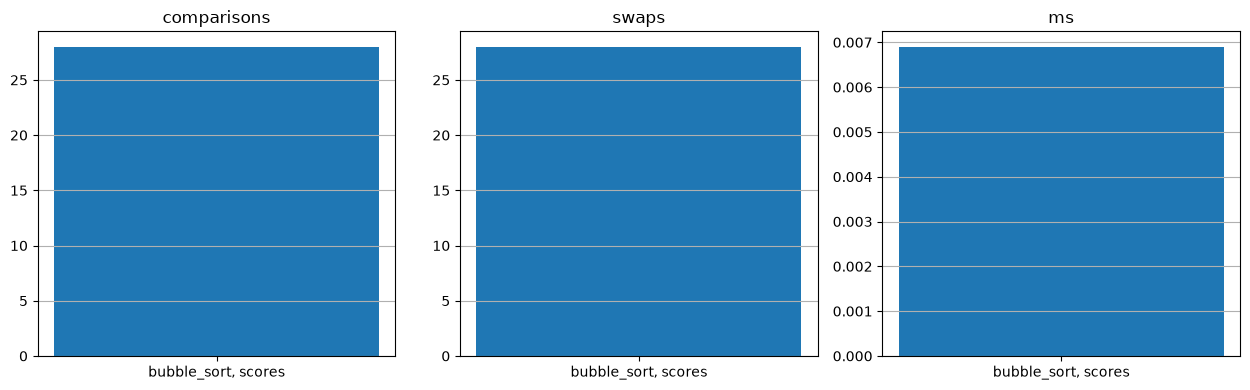

In [ ]:
bub.plot(('comparisons', 'swaps', 'ms'))

#### min_element 

In [ ]:
#| exports algorithms.sort
from programming_first_principles.ordering import out_of_order

def min_element(seq, first, last):
    """
    Returns the index of the minimum element in the range [first, last).
    """
    if first == last:
        return last
    min_index = first
    for i in range(first + 1, last):
        if out_of_order(seq[min_index],seq[i]):
            min_index = i
    return min_index

In [ ]:
scores_me = list(scores_out_of_100)
f'{scores_me = }'
f'{min_element(scores_me, 0, len(scores_me)) = }'
f'{scores_me[3] = }, {scores_me[6] = }'
f'{scores_me[4:7] = }, {min_element(scores_me, 4, 7) = }'
f'{scores_me[4:4] = }, {min_element(scores_me, 4, 4) = }'

'scores_me = [40, 10, 35, 5, 80, 75, 5, 80]'

'min_element(scores_me, 0, len(scores_me)) = 3'

'scores_me[3] = 5, scores_me[6] = 5'

'scores_me[4:7] = [80, 75, 5], min_element(scores_me, 4, 7) = 6'

'scores_me[4:4] = [], min_element(scores_me, 4, 4) = 4'

In [ ]:
min_m = Cost(repeats=1)
scores_min_m = list(scores_out_of_100)
f'{scores_min_m = }'
_ = min_m.run(min_element, scores_min_m, 0, len(scores_min_m),
                name='min_element', 
                shape='full range', 
                operations=('comparisons','ms'))
_ = min_m.run(min_element, scores_min_m, 4, 7,
                name='min_element', 
                shape='range of 3', 
                operations=('comparisons','ms'))
_ = min_m.run(min_element, scores_min_m, 4, 4,
                name='min_element', 
                shape='empty', 
                operations=('comparisons','ms'))
min_m.frame

'scores_min_m = [40, 10, 35, 5, 80, 75, 5, 80]'

,algo,shape,n,comparisons,predicates,swaps,ms
0,min_element,full range,8,7,None,None,0.0031
1,min_element,range of 3,8,2,None,None,0.0025
2,min_element,empty,8,0,None,None,0.0016


In [ ]:
#| exports algorithms.sort
def min_element_py(seq, first, last):
    return min(range(first, last), key=partial(getitem, seq), default=last)

#### max_element

In [ ]:
#| exports algorithms.sort
from programming_first_principles.ordering import in_order
def max_element(seq, first, last):
    """ 
    Returns the index of the maximum element in the range [first, last).
    """
    if first == last:
        return last
    max_index = first
    for i in range(first + 1, last):
        if in_order(seq[max_index],seq[i]):
            max_index = i
    return max_index

In [ ]:
scores_max_e = list(scores_out_of_100)
f'{scores_max_e = }'

f'{max_element(scores_max_e, 0, len(scores_max_e)) = }'
f'{scores_max_e[4] = }, {scores_max_e[-1] = }'
f'{scores_max_e[:5] = }, {max_element(scores_max_e, 0, 5) = }'
f'{scores_max_e[4:4] = }, {max_element(scores_max_e, 4, 4) = }'    

'scores_max_e = [40, 10, 35, 5, 80, 75, 5, 80]'

'max_element(scores_max_e, 0, len(scores_max_e)) = 7'

'scores_max_e[4] = 80, scores_max_e[-1] = 80'

'scores_max_e[:5] = [40, 10, 35, 5, 80], max_element(scores_max_e, 0, 5) = 4'

'scores_max_e[4:4] = [], max_element(scores_max_e, 4, 4) = 4'

In [ ]:
max_m = Cost(repeats=1)
scores_max_m = list(scores_out_of_100)
f'{scores_max_m = }'
_ = max_m.run(max_element, scores_max_m, 0, len(scores_max_m),
              name='max_element', shape='full range', operations=('comparisons', 'ms'))
_ = max_m.run(max_element, scores_max_m, 0, 5,
              name='max_element', shape='range of 5', operations=('comparisons', 'ms'))
_ = max_m.run(max_element, scores_max_m, 4, 4,
              name='max_element', shape='empty', operations=('comparisons', 'ms'))
max_m.frame

'scores_max_m = [40, 10, 35, 5, 80, 75, 5, 80]'

,algo,shape,n,comparisons,predicates,swaps,ms
0,max_element,full range,8,7,None,None,0.0027
1,max_element,range of 5,8,4,None,None,0.0030
2,max_element,empty,8,0,None,None,0.0011


In [ ]:
def max_element_py(seq, first, last):
    return max(range(last - 1, first - 1, -1), key=partial(getitem, seq), default=last)

#### minmax_element

In [ ]:
#| exports algorithms.sort
from programming_first_principles.ordering import out_of_order, in_order
def minmax_element(seq, first, last):
    """
    Returns the index of the minimum and maximum elements in the range [first, last).
    """
    if first == last:
        return last, last
    lo = hi = first
    for i in range(first + 1, last):
        if out_of_order(seq[lo], seq[i]):
            lo = i
        if in_order(seq[hi], seq[i]):
            hi = i
    return lo, hi

In [ ]:
scores_minmax_e = list(scores_out_of_100)
f'{scores_minmax_e = }'

f'{minmax_element(scores_minmax_e, 0, len(scores_minmax_e)) = }'

f'{scores_minmax_e[:5] = }, {minmax_element(scores_minmax_e, 0, 5) = }'
f'{scores_minmax_e[4:4] = }, {minmax_element(scores_minmax_e, 4, 4) = }'    

'scores_minmax_e = [40, 10, 35, 5, 80, 75, 5, 80]'

'minmax_element(scores_minmax_e, 0, len(scores_minmax_e)) = (3, 7)'

'scores_minmax_e[:5] = [40, 10, 35, 5, 80], minmax_element(scores_minmax_e, 0, 5) = (3, 4)'

'scores_minmax_e[4:4] = [], minmax_element(scores_minmax_e, 4, 4) = (4, 4)'

#### Selection Sort

* Selection sort always does n(n − 1) / 2 comparisons. Swaps stay between 0 and n − 1.
* **sorted**, 0 swaps (min_element keeps the leftmost minimum, and a nondecreasing range already has it at i)
* **reversed, distinct values**: n − 1 swaps

In [ ]:
#| exports algorithms.sort
from programming_first_principles.algorithms.rearrange import swap
from programming_first_principles.algorithms.sort import min_element, is_sorted

def selection_sort(a, first, last):
    for i in range(first, last):
        m = min_element(a, i, last)
        if m != i:
            swap(a, i, m)

In [ ]:
a = list(scores_out_of_100)
f'Before: {a = }, {is_sorted(a, 0, len(a)) = }'
selection_sort(a, 0, len(a))
f'After: {a = }, {is_sorted(a, 0, len(a)) = }'

sub = list(scores_out_of_100)
f'Before: {sub = }'
selection_sort(sub, 2, 6)
f'After:  {sub = }'

'Before: a = [40, 10, 35, 5, 80, 75, 5, 80], is_sorted(a, 0, len(a)) = False'

'After: a = [5, 5, 10, 35, 40, 75, 80, 80], is_sorted(a, 0, len(a)) = True'

'Before: sub = [40, 10, 35, 5, 80, 75, 5, 80]'

'After:  sub = [40, 10, 5, 35, 75, 80, 5, 80]'

In [ ]:
scores_ss = list(scores_out_of_100)
sel = Cost(repeats=1)
_ = sel.run(selection_sort, scores_ss.copy(), 0, len(scores_ss),
        name='selection_sort', shape='scores_ss',
        operations=('comparisons', 'swaps', 'ms'))
sel.frame

,algo,shape,n,comparisons,predicates,swaps,ms
0,selection_sort,scores_ss,8,28,None,5,0.1022


In [ ]:
sel = Cost(repeats=3, sizes=(200, 400, 800))
sel.scale(selection_sort, operations=('comparisons', 'swaps', 'ms'))

,algo,shape,n,comparisons,predicates,swaps,ms
0,selection_sort,random,200,19900,None,193,0.8999
1,selection_sort,sorted,200,19900,None,0,0.8464
2,selection_sort,reversed,200,19900,None,101,0.9193
3,selection_sort,random,400,79800,None,388,4.2010
4,selection_sort,sorted,400,79800,None,0,5.0034
5,selection_sort,reversed,400,79800,None,208,4.0640
6,selection_sort,random,800,319600,None,794,20.6623
7,selection_sort,sorted,800,319600,None,0,13.8053
8,selection_sort,reversed,800,319600,None,412,15.1840


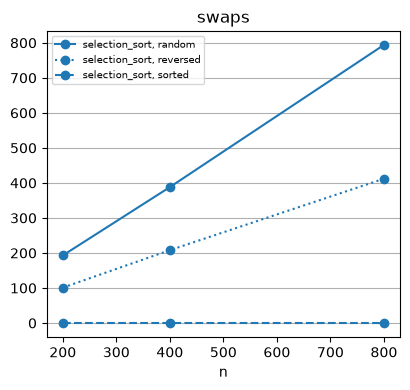

In [ ]:
sel.plot('swaps')